## Лабораторна робота №4
### Візуалізація даних 2: Дослідження зашумлених сигналів та цифрова фільтрація

### Мета роботи:
- Навчитися моделювати гармонічні сигнали з параметричним шумом.
- Дослідити ефективність цифрової фільтрації (Butterworth low-pass filter).
- Розробити інтерактивний інтерфейс для аналізу сигналів у реальному часі.

### Контекст кібербезпеки:
Методи обробки та фільтрації сигналів є фундаментальними для:
- Аналізу завад: виявлення та нейтралізація Jamming-атак у каналах зв'язку.
- Біометрії: очищення сигналів від шумів.
- Моніторингу: виявлення аномалій (DDoS).

### Інструкція користувача:
1. Параметри гармоніки: `Amplitude`, `Frequency`, `Phase`.
2. Параметри шуму: `Mean`, `Variance` (шум НЕ перегенерується при зміні гармоніки).
3. Фільтрація: `Cutoff`, `Order`.
4. Reset: повертає початкові значення.

##### 1. Імпорти

In [16]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import ipywidgets as widgets
from IPython.display import display

print("Бібліотеки готові до роботи")

Бібліотеки готові до роботи


##### 2. Функції

In [17]:
def harmonic_with_noise(t, amplitude, frequency, phase, noise_mean, noise_covariance, show_noise, existing_noise=None):
    """Генерує чисту гармоніку та зашумлений сигнал."""
    y_clean = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    
    if existing_noise is None:
        noise = np.random.normal(noise_mean, np.sqrt(noise_covariance), size=t.shape)
    else:
        noise = existing_noise
        
    y_noisy = y_clean + noise if show_noise else y_clean
    return y_clean, y_noisy, noise


def filter_signal(y, cutoff, fs, order):
    """Фільтр Баттерворта."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, y)

##### 3. Дані

In [18]:
t = np.linspace(0, 2, 1000)
fs = 1 / (t[1] - t[0])

# Початковий стабільний шум
current_noise = np.random.normal(0, np.sqrt(0.1), size=t.shape)

##### 4. Графіки 

Text(0.5, 1.0, 'Результат фільтрації')

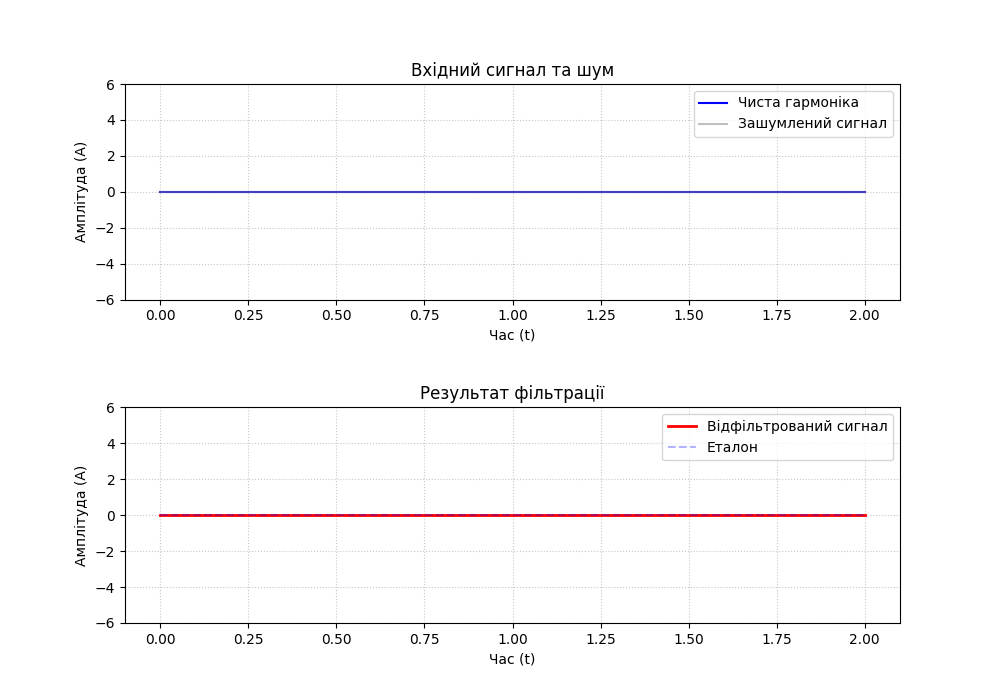

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
plt.subplots_adjust(hspace=0.5)

line_clean, = ax1.plot(t, np.zeros_like(t), 'b-', label='Чиста гармоніка')
line_noisy, = ax1.plot(t, np.zeros_like(t), color='gray', alpha=0.5, label='Зашумлений сигнал')

line_filt, = ax2.plot(t, np.zeros_like(t), 'r-', lw=2, label='Відфільтрований сигнал')
line_ref, = ax2.plot(t, np.zeros_like(t), 'b--', alpha=0.3, label='Еталон')

for ax in [ax1, ax2]:
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')
    ax.set_ylim(-6, 6)
    ax.set_xlabel("Час (t)")
    ax.set_ylabel("Амплітуда (A)")

ax1.set_title("Вхідний сигнал та шум")
ax2.set_title("Результат фільтрації")

##### 5. UI

In [20]:
style = {'description_width': '100px'}

amp_w = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, description='Амплітуда:', style=style)
freq_w = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, description='Частота:', style=style)
phase_w = widgets.FloatSlider(value=0.0, min=0, max=2*np.pi, description='Фаза:', style=style)

mean_w = widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.05, description='Шум (Mean):', style=style)
cov_w = widgets.FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='Шум (Var):', style=style)
show_w = widgets.Checkbox(value=True, description='Показати шум')

cut_w = widgets.FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1, description='Зріз (Hz):', style=style)
ord_w = widgets.IntSlider(value=4, min=1, max=10, description='Порядок:', style=style)

reset_btn = widgets.Button(description="Скинути параметри", button_style='danger')

##### 6. Логіка

In [27]:
def update_plot(_=None):
    y_clean, y_noisy, _ = harmonic_with_noise(
        t, amp_w.value, freq_w.value, phase_w.value,
        mean_w.value, cov_w.value, show_w.value,
        existing_noise=current_noise
    )
    
    y_filtered = filter_signal(y_noisy, cut_w.value, fs, ord_w.value)
    
    line_clean.set_ydata(y_clean)
    line_noisy.set_ydata(y_noisy if show_w.value else y_clean)
    line_filt.set_ydata(y_filtered)
    line_ref.set_ydata(y_clean)
    
    fig.canvas.draw_idle()

def on_noise_change(change):
    global current_noise
    current_noise = np.random.normal(mean_w.value, np.sqrt(cov_w.value), size=t.shape)
    update_plot(None)

def reset_all(b=None):
    amp_w.value = 1.0
    freq_w.value = 1.0
    phase_w.value = 0.0
    mean_w.value = 0.0
    cov_w.value = 0.1
    show_w.value = True
    cut_w.value = 2.0
    ord_w.value = 4
    
    on_noise_change(None)

reset_btn.on_click(reset_all)

##### 7. Підключення UI

In [28]:
for w in [amp_w, freq_w, phase_w, show_w, cut_w, ord_w]:
    w.observe(update_plot, names='value')

mean_w.observe(on_noise_change, names='value')
cov_w.observe(on_noise_change, names='value')

reset_btn.on_click(reset_all)

##### 8. Відображення

In [29]:
ui = widgets.VBox([
    widgets.Label(value="Параметри гармоніки:"),
    widgets.HBox([amp_w, freq_w, phase_w]),

    widgets.Label(value="Параметри шуму:"),
    widgets.HBox([mean_w, cov_w, show_w]),

    widgets.Label(value="Налаштування фільтра:"),
    widgets.HBox([cut_w, ord_w, reset_btn])
])

display(ui)
update_plot()